In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse import diags
from scipy.sparse.linalg import spsolve


def expand_regions(regions):
    D, Sa, nSf, dx = [], [], [], []

    for reg in regions:
        Nc = reg["Nc"]
        D.extend([reg["D"]] * Nc)
        Sa.extend([reg["Sigma_a"]] * Nc)
        nSf.extend([reg["nuSigma_f"]] * Nc)
        dx.extend([reg["dx"]] * Nc)

    D = np.array(D, dtype=float)
    Sa = np.array(Sa, dtype=float)
    nSf = np.array(nSf, dtype=float)
    dx = np.array(dx, dtype=float)

    x_edges = np.concatenate(([0.0], np.cumsum(dx)))
    x_centers = 0.5 * (x_edges[:-1] + x_edges[1:])

    return x_centers, D, Sa, nSf, dx


def build_loss_matrix(D, Sa, dx):
    N = len(D)

    lower = np.zeros(N)
    diag = np.zeros(N)
    upper = np.zeros(N)

    # Interior interface conductances
    F = np.zeros(N - 1)
    for i in range(N - 1):
        F[i] = 1.0 / (0.5 * dx[i] / D[i] + 0.5 * dx[i+1] / D[i+1])

    for i in range(N):
        diag[i] += Sa[i] * dx[i]

        if i > 0:
            lower[i] = -F[i-1]
            diag[i] += F[i-1]

        if i < N - 1:
            upper[i] = -F[i]
            diag[i] += F[i]

    # Left boundary: dphi/dx = 0, so no extra leakage term

    # Right boundary: Jminus = 0
    # Jminus = phi/4 + (D/2)dphi/dx
    beta = 2.0 * D[-1] / dx[-1]
    alpha = beta / (2.0 * beta + 1.0)

    diag[-1] += alpha

    A = diags(
        diagonals=[lower[1:], diag, upper[:-1]],
        offsets=[-1, 0, 1],
        format="csr"
    )

    return A


def solve_k_eigenvalue(
    regions,
    k_tol=1e-8,
    source_tol=1e-8,
    max_iters=500
):
    x, D, Sa, nSf, dx = expand_regions(regions)
    N = len(x)

    A = build_loss_matrix(D, Sa, dx)

    k = 1.0
    phi = np.ones(N)

    fission_source = nSf * phi * dx
    fission_source /= np.sum(fission_source)

    k_history = [k]

    for it in range(1, max_iters + 1):

        rhs = fission_source / k

        phi_new = spsolve(A, rhs)

        fission_source_raw = nSf * phi_new * dx

        k_new = k * np.sum(fission_source_raw) / np.sum(fission_source)

        fission_source_new = fission_source_raw / np.sum(fission_source_raw)
        phi_new /= np.sum(fission_source_raw)

        k_error = abs(k_new - k) / abs(k_new)

        source_error = np.linalg.norm(
            fission_source_new - fission_source,
            ord=np.inf
        ) / np.linalg.norm(fission_source_new, ord=np.inf)

        k_history.append(k_new)

        if k_error < k_tol and source_error < source_tol:
            return x, phi_new, k_new, np.array(k_history), it

        k = k_new
        phi = phi_new
        fission_source = fission_source_new

    print("ERROR: Power iteration failed to converge within the maximum number of iterations.")
    return x, phi, k, np.array(k_history), max_iters


def plot_k_eigenvalue_results(x, phi, k_history):
    plt.figure(figsize=(8, 5))
    plt.scatter(x, phi)
    plt.xlabel("x")
    plt.ylabel(r"Relative flux $\phi$")
    plt.title("Final relative flux distribution")
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(np.arange(len(k_history)), k_history, marker="o")
    plt.xlabel("Power iteration")
    plt.ylabel(r"$k$")
    plt.title("k-eigenvalue convergence")
    plt.grid(True)
    plt.show()

k = 1.09987161
Power iterations = 26


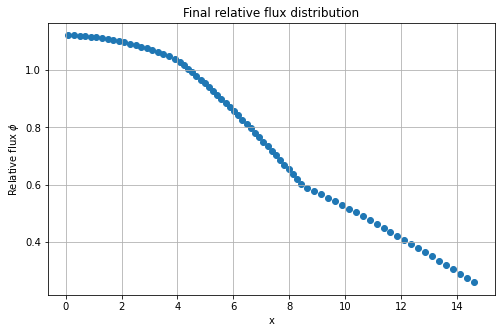

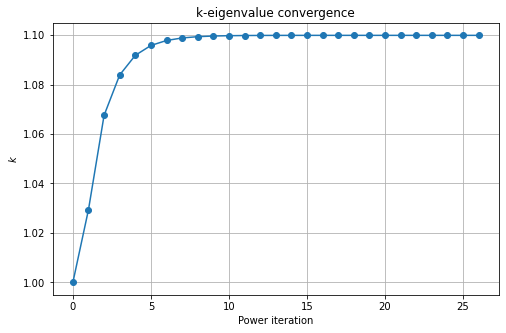

In [2]:
regions_3 = [
    {
        "Nc": 20,
        "D": 1.5,
        "Sigma_a": 0.04,
        "nuSigma_f": 0.060,
        "dx": 0.20,
    },
    {
        "Nc": 30,
        "D": 0.8,
        "Sigma_a": 0.12,
        "nuSigma_f": 0.140,
        "dx": 0.15,
    },
    {
        "Nc": 25,
        "D": 2.0,
        "Sigma_a": 0.06,
        "nuSigma_f": 0.080,
        "dx": 0.25,
    },
]

x, phi, k, k_history, num_iters = solve_k_eigenvalue(
    regions_3,
    k_tol=1e-8,
    source_tol=1e-8,
    max_iters=500
)

print(f"k = {k:.8f}")
print(f"Power iterations = {num_iters}")

plot_k_eigenvalue_results(x, phi, k_history)